# Enhanced capabilities

This notebook highlights additional capabilities available in the current `jupyter_tikz` API.


## What is new
- Multiple toolchains (`pdftex`/`xelatex` with `pdftocairo`/`pdf2svg`/`dvisvgm`)
- Crop policies (`crop="tight"|"page"|"none"`) and exact bbox
- SVG padding with numeric/tuple/dict inputs
- Canvas frame overlay (`frame=...`) for debugging or presentation
- Artifact capture via `render_svg_with_artifacts(...)`, directory-based `artifacts_path=...`, and explicit `artifacts_prefix=...`
- SVG XML/doctype normalization toggle via `strip_xml_declaration`


In [1]:
# helper routine
from pathlib import Path
def _find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for candidate in [p, *p.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "docs").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")

## Toolchains

In [2]:
import jupyter_tikz as jt

try:
    from jupyter_tikz import TOOLCHAINS
except ImportError:
    try:
        from jupyter_tikz.toolchains import TOOLCHAINS
    except Exception as exc:
        raise ImportError(
            "This notebook requires a jupyter_tikz build with toolchain support "
            "(executor/toolchains API). Install from this repository checkout."
        ) from exc

sorted(TOOLCHAINS.keys())


['pdftex_dvisvgm',
 'pdftex_pdf2svg',
 'pdftex_pdftocairo',
 'xelatex_dvisvgm',
 'xelatex_pdf2svg',
 'xelatex_pdftocairo']

### Toolchain diagnostics

Use the diagnostics helpers to inspect which binaries are available in the current environment.

In [3]:
from jupyter_tikz import check_toolchains, check_toolchain
check_toolchains()

{'pdftex_dvisvgm': {'name': 'pdftex_dvisvgm',
  'latex_bin': 'latexmk',
  'latex_path': '/usr/bin/latexmk',
  'svg_bin': 'dvisvgm',
  'svg_path': '/usr/bin/dvisvgm',
  'available': True},
 'pdftex_pdf2svg': {'name': 'pdftex_pdf2svg',
  'latex_bin': 'latexmk',
  'latex_path': '/usr/bin/latexmk',
  'svg_bin': 'pdf2svg',
  'svg_path': '/usr/bin/pdf2svg',
  'available': True},
 'pdftex_pdftocairo': {'name': 'pdftex_pdftocairo',
  'latex_bin': 'latexmk',
  'latex_path': '/usr/bin/latexmk',
  'svg_bin': 'pdftocairo',
  'svg_path': '/usr/bin/pdftocairo',
  'available': True},
 'xelatex_dvisvgm': {'name': 'xelatex_dvisvgm',
  'latex_bin': 'latexmk',
  'latex_path': '/usr/bin/latexmk',
  'svg_bin': 'dvisvgm',
  'svg_path': '/usr/bin/dvisvgm',
  'available': True},
 'xelatex_pdf2svg': {'name': 'xelatex_pdf2svg',
  'latex_bin': 'latexmk',
  'latex_path': '/usr/bin/latexmk',
  'svg_bin': 'pdf2svg',
  'svg_path': '/usr/bin/pdf2svg',
  'available': True},
 'xelatex_pdftocairo': {'name': 'xelatex_pdf

### Magic diagnostics examples

The `%tikz` magic supports diagnostics mode via `-dg/--diagnose`. Use `-j/--json` for JSON output (legacy `-json` is also accepted).

In [4]:
%load_ext jupyter_tikz

# Human-readable diagnostics
%tikz -dg

# JSON diagnostics (preferred short flag)
%tikz -dg -j

# JSON diagnostics (legacy alias, still supported)
%tikz -dg -json

jupyter_tikz toolchain diagnostics:
- pdftex_dvisvgm: ok | latexmk=/usr/bin/latexmk | dvisvgm=/usr/bin/dvisvgm
- pdftex_pdf2svg: ok | latexmk=/usr/bin/latexmk | pdf2svg=/usr/bin/pdf2svg
- pdftex_pdftocairo: ok | latexmk=/usr/bin/latexmk | pdftocairo=/usr/bin/pdftocairo
- xelatex_dvisvgm: ok | latexmk=/usr/bin/latexmk | dvisvgm=/usr/bin/dvisvgm
- xelatex_pdf2svg: ok | latexmk=/usr/bin/latexmk | pdf2svg=/usr/bin/pdf2svg
- xelatex_pdftocairo: ok | latexmk=/usr/bin/latexmk | pdftocairo=/usr/bin/pdftocairo
{
  "requested_toolchain": null,
  "toolchains": [
    {
      "available": true,
      "latex_bin": "latexmk",
      "latex_path": "/usr/bin/latexmk",
      "name": "pdftex_dvisvgm",
      "svg_bin": "dvisvgm",
      "svg_path": "/usr/bin/dvisvgm"
    },
    {
      "available": true,
      "latex_bin": "latexmk",
      "latex_path": "/usr/bin/latexmk",
      "name": "pdftex_pdf2svg",
      "svg_bin": "pdf2svg",
      "svg_path": "/usr/bin/pdf2svg"
    },
    {
      "available": true,
 

## Cropping and Padding

In [5]:
from jupyter_tikz import TexFragment, render_svg
from IPython.display import SVG, display

tikz = r"""
  \draw[very thick, blue] (0,0) rectangle (2,1);
  \draw[red, thick, ->] (0,0) -- (2,1);
  \node[anchor=west] at (2.1,0.5) {demo};
"""

# With implicit_tikzpicture=True, the fragment is wrapped in a tikzpicture env.
doc = TexFragment(tikz, implicit_tikzpicture=True)

svg = render_svg(doc.full_latex)
display(SVG(svg))


In [6]:
svg = render_svg(
    doc.full_latex,
    toolchain_name="pdftex_dvisvgm",
    crop="tight",
    exact_bbox=True,
)

display(SVG(svg))

## Adding a Frame

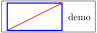

In [7]:
svg = render_svg(
    doc.full_latex,
    crop="tight",
    padding={"x": 6, "y": 2},
    frame={"stroke": "#444444", "stroke_width": 0.6, "inset": 1},
    strip_xml_declaration=True,
)

display(SVG(svg))

## Output Directory and File Prefiix

In [8]:
from jupyter_tikz import render_svg, render_svg_with_artifacts

repo_root = _find_repo_root(Path.cwd())
out_dir = repo_root / "notebooks" / "outputs" / "enhancements-demo"
out_dir.mkdir(parents=True, exist_ok=True)

artifacts = render_svg_with_artifacts(
    doc.full_latex,
    output_dir=out_dir,
    output_stem="demo",
    crop="tight",
)

# Directory-based retention (consistent with keep-temp directory behavior).
svg_kept = render_svg(doc.full_latex, artifacts_path=out_dir / "kept")

# Optional explicit prefix retention when you want fixed artifact names.
svg_kept_prefix = render_svg(doc.full_latex, artifacts_prefix=out_dir / "demo-prefix")

{
    "workdir": str(artifacts.workdir),
    "svg_path": str(artifacts.svg_path),
    "stderr_path": str(artifacts.stderr_path),
    "svg_preview": artifacts.read_svg()[:120],
    "svg_kept_preview": svg_kept[:120],
    "svg_kept_prefix_preview": svg_kept_prefix[:120],
}


{'workdir': '/home/lab/NOTEBOOKS/0_ITIKZ/jupyter_tikz/notebooks/outputs/enhancements-demo',
 'svg_path': '/home/lab/NOTEBOOKS/0_ITIKZ/jupyter_tikz/notebooks/outputs/enhancements-demo/demo.svg',
 'stderr_path': '/home/lab/NOTEBOOKS/0_ITIKZ/jupyter_tikz/notebooks/outputs/enhancements-demo/demo.stderr.txt',
 'svg_preview': '<svg\n   width="85.2826"\n   height="29.645939"\n   viewBox="0 0 85.282602 29.645939"\n   version="1.1"\n   id="svg44"\n   sod',
 'svg_kept_preview': '<svg\n   width="85.2826"\n   height="29.645939"\n   viewBox="0 0 85.282602 29.645939"\n   version="1.1"\n   id="svg44"\n   sod',
 'svg_kept_prefix_preview': '<svg\n   width="85.2826"\n   height="29.645939"\n   viewBox="0 0 85.282602 29.645939"\n   version="1.1"\n   id="svg44"\n   sod'}

## Invalid output path example

The following command intentionally fails because relative `..` path segments are rejected for user-provided output paths.

In [9]:
# Expected error (stderr):
# keep-temp directory must not contain '..' path segments
%%tikz --keep-temp ../bad --no-compile
\draw (0,0) -- (1,1);

SyntaxError: unexpected character after line continuation character (3484986322.py, line 4)

In [10]:
# Cleanup
import shutil
from pathlib import Path

# Cleanup generated enhancement artifacts.
repo_root = _find_repo_root(Path.cwd())
target = repo_root / "notebooks" / "outputs" / "enhancements-demo"
if target.exists():
    shutil.rmtree(target)
    print(f"Removed: {target}")
else:
    print(f"Nothing to remove: {target}")


Removed: /home/lab/NOTEBOOKS/0_ITIKZ/jupyter_tikz/notebooks/outputs/enhancements-demo
